# Technology for Energy systems integration - Final Assignment
## Energy transition study with integration of multiple energy carriers

POINT 1: Design of renewable production, electricity transmission and storage for given demand and constraints

In [3]:
from math import nan

import pandas as pd
import numpy as np
import requests
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pvlib

In [4]:
# Given information:
node_lat = 54.6172
node_lon = 9.5776
node_alt = 0

distance12 = 53 #km

electricity_demand_multiplier = 0.54
heat_demand_multiplier = 0.43

In [5]:
# Create time series with hourly resolution for the given period
year = 2009
month = 2
times = pd.date_range(start='2009-02-01', end='2009-02-28 23:59:59', freq='h', tz='Europe/Amsterdam')

In [6]:
# Function to import climate data from JRC - DO NOT CHANGE

def import_jrc_climate_data(lon: float, lat: float, year: int | str, alt: float) -> dict:
    """
    Reads in climate data for a full year from `JRC PVGIS <https://re.jrc.ec.europa.eu/pvg_tools/en/>`_.

    :param float lon: longitude of node - the api will read data for this location
    :param float lat: latitude of node - the api will read data for this location
    :param int year: optional, needs to be in range of data available. If nothing is specified, a typical year \
    will be loaded
    :param float alt: altitude of location specified
    :return: dict containing information on the location (altitude, longitude, latitude and a dataframe \
    containing climate data (ghi = global horizontal irradiance, dni = direct normal irradiance, \
    dhi = diffuse horizontal irradiance, rh = relative humidity, temp_air = air temperature, ws = wind speed at \
    specified hight. Wind speed is returned as a dict for different heights.
    :rtype: dict
    """

    # Specify year import, lon, lat
    parameters = {"lon": lon, "lat": lat, "year": year, "outputformat": "json"}
    time_index = pd.date_range(
        start=str(year) + "-01-01 00:00", end=str(year) + "-12-31 23:00", freq="1h"
    )

    # Get data from JRC dataset
    answer = dict()
    print("Importing Climate Data...")
    response = requests.get("https://re.jrc.ec.europa.eu/api/tmy?", params=parameters)
    if response.status_code == 200:
        print("Importing Climate Data successful")
    else:
        raise Exception(response)
    data = response.json()
    climate_data = data["outputs"]["tmy_hourly"]

    # Compile return dict
    answer["longitude"] = lon
    answer["latitude"] = lat
    answer["altitude"] = alt

    ghi = []
    dni = []
    dhi = []
    rh = []
    temp_air = []
    wind_speed = dict()
    wind_speed["10"] = []

    for t_interval in climate_data:
        ghi.append(t_interval["G(h)"])
        dni.append(t_interval["Gb(n)"])
        dhi.append(t_interval["Gd(h)"])
        rh.append(t_interval["RH"])
        temp_air.append(t_interval["T2m"])
        wind_speed["10"].append(t_interval["WS10m"])

    answer["dataframe"] = pd.DataFrame(
        np.array([ghi, dni, dhi, temp_air, rh]).T,
        columns=["ghi", "dni", "dhi", "temp_air", "rh"],
        index=time_index,
    )
    for ws in wind_speed:
        answer["dataframe"]["ws" + str(ws)] = wind_speed[ws]

    return answer

In [7]:
# Import climate data

climate_data = import_jrc_climate_data(node_lon, node_lat, year, node_alt)

Importing Climate Data...
Importing Climate Data successful


In [8]:
# Create wind turbine power curve function - DO NOT CHANGE
name = "WindTurbine_Onshore_4000"
wt_data_path = 'data/WT_data.csv'
wt_data_full = pd.read_csv(wt_data_path, delimiter=";")
# match WT with data
wt_data = wt_data_full[wt_data_full["TurbineName"] == name]
hubheight = 120

# Make power curve
rated_capacity = wt_data.iloc[0]["RatedPowerkW"]
wind_speed = np.linspace(0, 35, 71)
power_output = wt_data.iloc[:, 13:84]
power_output = power_output.to_numpy()

f = interp1d(wind_speed, power_output)

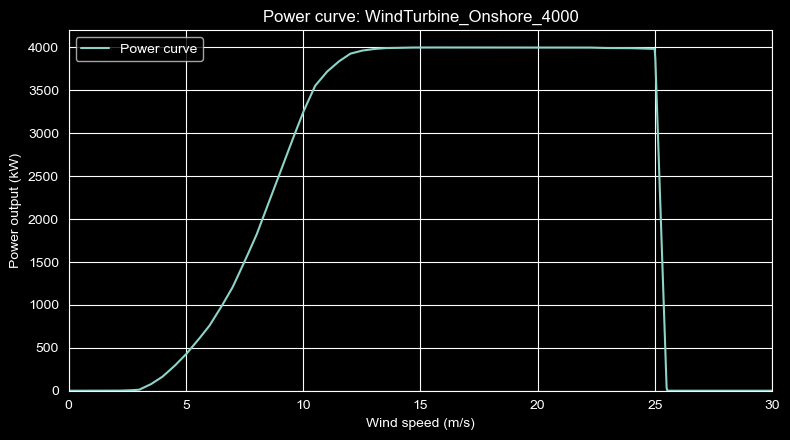

In [9]:
# Vizualize power curve

x_plot = np.linspace(0, 30, 1000)
y_plot = f(x_plot).ravel()

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_plot, label="Power curve")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power output (kW)")
plt.title(f"Power curve: {name}")
plt.legend()
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, max(float(rated_capacity) * 1.05, power_output.max() * 1.05))
plt.tight_layout()
plt.show()

In [10]:
# Weather data - DO NOT CHANGE
df = climate_data['dataframe']

if "ws100" in df.columns:
    ws = df["ws100"]
    ws_height = 100
else:
    ws = df["ws10"]
    ws_height = 10

alpha = 1/7

if hubheight > 0:
    ws = ws * (hubheight / ws_height) ** alpha

In [11]:
# defining pv data - DO NOT CHANGE

pv_system_data = dict()
pv_system_data["tilt"] = 18
pv_system_data["surface_azimuth"] = 180
pv_system_data["module_name"] = "SunPower_SPR_X20_327"
pv_system_data["inverter_eff"] = 0.96

inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

In [12]:
# Fitting pv system - DO NOT CHANGE
module_database = pvlib.pvsystem.retrieve_sam("CECMod")
module = module_database[pv_system_data["module_name"]]

temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"][
        "open_rack_glass_glass"
    ]
)

# Create PV model chain
inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

system = pvlib.pvsystem.PVSystem(
    surface_tilt=pv_system_data["tilt"],
    surface_azimuth=pv_system_data["surface_azimuth"],
    module_parameters=module,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
)

# Get location
tz = 'Europe/Amsterdam'

location = pvlib.location.Location(node_lat, node_lon, tz=tz, altitude=node_alt)

pv_model = pvlib.modelchain.ModelChain(
    system, location, spectral_model="no_loss", aoi_model="physical"
)
peakpower = module.STC

In [13]:
# Electricity and Heat demand data
import calendar

skip = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

demand_data_path = 'data/demand_production.xlsx'
df_p1 = pd.read_excel(demand_data_path, sheet_name='Point1', header=1)

el_demand   = df_p1['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
el_demand   = el_demand * electricity_demand_multiplier

heat_demand = df_p1['Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
heat_demand = heat_demand * heat_demand_multiplier

In [14]:
# Energy production

# Hours to skip to reach the selected month
skip_hours = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

# wind capacity factor
capacity_factor_wind = f(np.clip(ws.values, 0, 35)) / 4000
capacity_factor_wind = pd.Series(
    np.asarray(capacity_factor_wind).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

# solar capacity factor
pv_model.run_model(df)
power = pv_model.results.ac.p_mp
capacity_factor_solar = power / peakpower

capacity_factor_solar = pd.Series(
    np.asarray(capacity_factor_solar).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)
print(capacity_factor_wind)

C:\Users\Stefv\anaconda3\envs\pypsa_esi\Lib\site-packages\scipy\optimize\_chandrupatla.py:437: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


2009-02-01 00:00:00+01:00    0.286289
2009-02-01 01:00:00+01:00    0.222288
2009-02-01 02:00:00+01:00    0.166264
2009-02-01 03:00:00+01:00    0.120219
2009-02-01 04:00:00+01:00    0.079696
                               ...   
2009-02-28 19:00:00+01:00    0.014010
2009-02-28 20:00:00+01:00    0.012189
2009-02-28 21:00:00+01:00    0.009913
2009-02-28 22:00:00+01:00    0.008092
2009-02-28 23:00:00+01:00    0.006272
Freq: h, Length: 672, dtype: float64


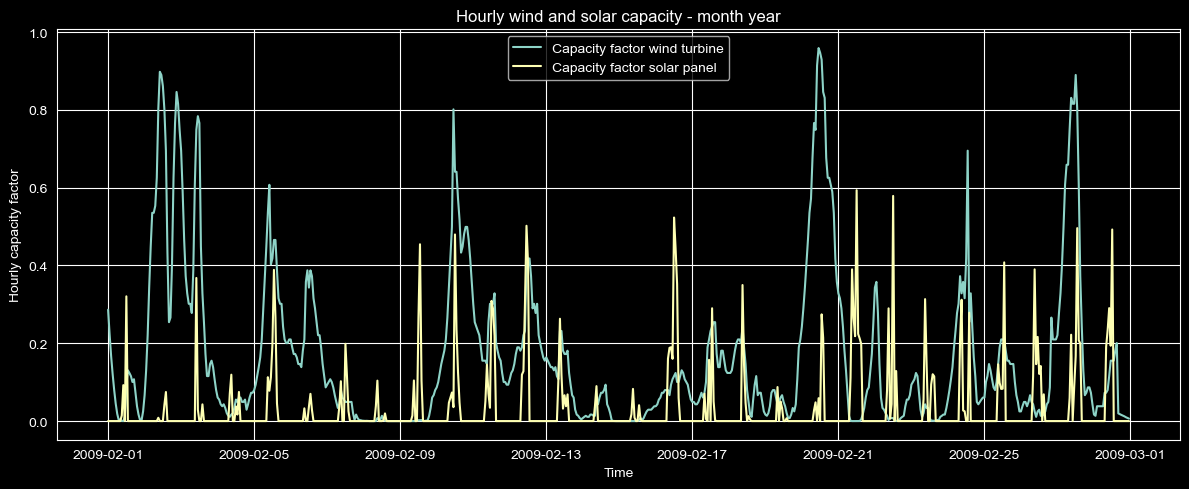

In [15]:
# Plot of capacity factors

plt.figure(figsize=(12, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - month year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Obtaining techno-economic data

tech_eco_data_path = 'data/technoeconomic_data.xlsx'
tech_eco_data = pd.read_excel(tech_eco_data_path, sheet_name='Data', header=2)

def get_value(df, component, data_type):
    mask = (df['component'] == component) & (df['parameter'] == data_type)
    result = df.loc[mask, 'value']
    if len(result) == 0:
        raise ValueError(f"No data found for component='{component}', parameter='{data_type}'")
    return result.values[0]

# We give you the wind turbine techno-economic data import as example. Save all the relevant data with the same function
# !!Make sure to use the correct units!!

# Wind turbine
Wind_capex = get_value(tech_eco_data, 'Wind turbine', 'Investment cost')  # EUR/kW
Wind_lifetime = get_value(tech_eco_data, 'Wind turbine', 'Lifetime')  # year
Wind_opex = get_value(tech_eco_data, 'Wind turbine', 'Opex') / 100  # % capex/year

In [228]:
# grab additional techno-economic data
Solar_capex = get_value(tech_eco_data, 'Solar panel', 'Investment cost')  #EUR/kw
Solar_lifetime = get_value(tech_eco_data, 'Solar panel', 'Lifetime') # year
Solar_opex = get_value(tech_eco_data, 'Solar panel', 'Opex') / 100 # % capex/year
Electricity_cable_capex = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') #EUR/kw/km
Electricity_cable_lifetime = get_value(tech_eco_data, 'Electricity cable', 'Lifetime') # year
Electricity_cable_fixed_opex = get_value(tech_eco_data, 'Electricity cable', 'Fixed Opex') / 100 # %capex/year
Electricity_cable_losses = get_value(tech_eco_data, 'Electricity cable', 'Losses') # % per 100km

# relevant for part 2
# Hydrogen_pipeline_capex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Investment cost') # Eur/kw/km
# Hydrogen_pipeline_lifetime = get_value(tech_eco_data, 'Hydrogen pipeline', 'Lifetime') # year
# Hydrogen_pipeline_fixed_opex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Fixed Opex') # % capex/year
# Hydrogen_pipeline_losses = get_value(tech_eco_data, 'Hydrogen pipeline', 'Losses') # % per 100km

Li_ion_battery_capex = get_value(tech_eco_data, 'Li-ion battery', 'Investment cost') # EUR/kWh
Li_ion_battery_lifetime = get_value(tech_eco_data, 'Li-ion battery', 'Lifetime') # year
Li_ion_battery_opex = get_value(tech_eco_data, 'Li-ion battery', 'Opex') / 100 # % capex/year
Li_ion_battery_charging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Charging efficiency') # % input energy
Li_ion_battery_discharging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Discharging efficiency') # % output energy
Li_ion_battery_self_discharge_coefficient = get_value(tech_eco_data, 'Li-ion battery', 'Self-discharge coefficient') # % per hour
Li_ion_battery_max_charging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max charging capacity') # % size of battery
Li_ion_battery_max_discharging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max discharging capacity') # % size of battery

# relevant for part 2
Hydrogen_storage_tank_capex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Investment cost') # EUR/kWh
Hydrogen_storage_tank_lifetime = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Lifetime') #year
Hydrogen_storage_tank_opex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Opex') # % capex/year
Hydrogen_storage_tank_charging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Charging efficiency') # % input energy
Hydrogen_storage_tank_discharging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank','Discharging efficiency') # % output energy
Hydrogen_storage_tank_self_discharge_coefficient = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Self-discharge coefficient') # %/hour
Hydrogen_storage_tank_max_charging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max charging capacity') # %/size
Hydrogen_storage_tank_max_discharging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max discharging capacity') # %/size
Hydrogen_storage_tank_max_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max capacity') # MW

Heat_storage_high_temp_capex = get_value(tech_eco_data, 'Heat storage - High temp', 'Investment cost') # EUR/MWh
Heat_storage_high_temp_lifetime = get_value(tech_eco_data, 'Heat storage - High temp', 'Lifetime') # year
Heat_storage_high_temp_opex = get_value(tech_eco_data, 'Heat storage - High temp', 'Opex') # % capex/year
Heat_storage_high_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp', 'Charging efficiency') # % input energy
Heat_storage_high_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp','Discharging efficiency') # % output energy
Heat_storage_high_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - High temp', 'Self-discharge coefficient') # % / hour
Heat_storage_high_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max charging capacity') # % size
Heat_storage_high_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max discharging capacity') # % size

Heat_storage_low_temp_capex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Investment cost') # EUR/MWh
Heat_storage_low_temp_lifetime = get_value(tech_eco_data, 'Heat storage - Low temp', 'Lifetime') # year
Heat_storage_low_temp_opex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Opex') # % capex/year
Heat_storage_low_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp', 'Charging efficiency') # % input energy
Heat_storage_low_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp','Discharging efficiency') # % output energy
Heat_storage_low_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - Low temp', 'Self-discharge coefficient') # % / hour
Heat_storage_low_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max charging capacity') # % size
Heat_storage_low_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max discharging capacity') # % size

Heat_pump_coefficient_of_performance = get_value(tech_eco_data, 'Heat pump', 'COP') # no unit
Hydrogen_boiler_efficiency = get_value(tech_eco_data, 'Hydrogen boiler', 'Efficiency') # % input energy
Operational_cost_lost_load_penalty = get_value(tech_eco_data, 'Operational cost', 'Lost load penalty') # EUR/MWh
Operational_cost_max_import_availability = get_value(tech_eco_data, 'Operational cost', 'Max import availability') # MWh
Operational_cost_electricity_import_cost = get_value(tech_eco_data, 'Operational cost', 'Electricity import cost') # EUR/MWh
Operational_cost_hydrogen_market_price = get_value(tech_eco_data, 'Operational cost', 'Hydrogen market price') # EUR/MWh


In [252]:
#Stocks
Solar_capacity = 150000             # kW  # 50000
Wind_capacity = 150000              # kW  # 50000
Battery_zone1_capacity = 50000     # kWh # 00000
Battery_zone2_capacity = 50000     # kWh # 25000
Cables_capacity = 50000            # kW; must be in increments of 10,000 kW # 30000

#Generation, demand, import and shortages
Wind_generation = Wind_capacity * capacity_factor_wind    # kWh
Solar_generation = Solar_capacity * capacity_factor_solar # kWh
Total_RES_generation = Wind_generation + Solar_generation # kWh

el_demand = df_p1['Electricity [MWh]'].iloc[skip : skip + len(times)] # MWh
el_demand = el_demand.set_axis(times) * 1000                          # kWh; multiplying by 1000 because previously in MWh
heat_demand = df_p1['Heat [MWh]'].iloc[skip : skip + len(times)]      # MWh
heat_demand = heat_demand.set_axis(times) * 1000                      # kWh

Residual_load = pd.Series(0.0, index=times)         # kWh
Electricity_import = pd.Series(0.0, index=times)    # kWh; Electricity that must be imported
Electricity_shortage = pd.Series(0.0, index=times)  # kWh; Electricity shortage

#Battery generic
ETA_charge = Li_ion_battery_charging_efficiency / 100             # eta is efficiency
ETA_discharge = Li_ion_battery_discharging_efficiency / 100       # eta is efficiency
Self_discharge = Li_ion_battery_self_discharge_coefficient / 100  # % per hour               # kW

#Battery zone 1
Battery_zone1_max_charge = (Li_ion_battery_max_charging_capacity / 100) * Battery_zone1_capacity        # kW
Battery_zone1_max_discharge = (Li_ion_battery_max_discharging_capacity / 100) * Battery_zone1_capacity  # kW
SOC_zone1 = pd.Series(0.0, index=times)          # State of charge
Charge_zone1 = pd.Series(0.0, index=times)       # Charging power
Discharge_zone1 = pd.Series(0.0, index=times)    # Discharging power
Leftover_load_zone1 = pd.Series(0.0, index=times)

#Battery zone 2
Battery_zone2_max_charge = (Li_ion_battery_max_charging_capacity / 100) * Battery_zone2_capacity        # kW
Battery_zone2_max_discharge = (Li_ion_battery_max_discharging_capacity / 100) * Battery_zone2_capacity  # kW
SOC_zone2 = pd.Series(0.0, index=times)          # State of charge
Charge_zone2 = pd.Series(0.0, index=times)       # Charging power
Discharge_zone2 = pd.Series(0.0, index=times)    # Discharging power
Leftover_load_zone2 = pd.Series(0.0, index=times)

#Generic set-up
hours = len(times)

In [253]:
# --- Loop over hours ---
for i, t in enumerate(times):
    Residual_load[t] = (Total_RES_generation[t] * (1 - (Electricity_cable_losses / 100) * (distance12 / 100))) - el_demand[t] # at zone 2 if not limited by cables
    Leftover_load_zone1[t] = Total_RES_generation[t] - min(el_demand[t] / (1 - (Electricity_cable_losses / 100) * (distance12 / 100)), Cables_capacity)
    Leftover_load_zone2[t] = min(Total_RES_generation[t] * (1 - (Electricity_cable_losses / 100) * (distance12 / 100)), Cables_capacity) - el_demand[t]

    # Leftover_load_zone1[t] = (el_demand[t] / (1 - (Electricity_cable_losses / 100) * (distance12 / 100))) - min(0, Cables_capacity - Total_RES_generation[t])
    #                           # use if RES is larger than cable capacity and so a battery at zone 1 can be charged more. This might not be working correctly, so I took it out. Change 'Residual_load' in battery for zone 1 (below) to 'Leftover_load_zone1' if we want to implement again. Right now, if the cables are "full", the leftover power at zone 1 is wasted if its battery is full too.
    # Leftover_load_zone2[t] = min(0, Cables_capacity, (Residual_load[t] / (1 - (Electricity_cable_losses / 100) * (distance12 / 100))))

    Prev_SOC_zone1 = SOC_zone1.iloc[i-1] if i > 0 else (Battery_zone1_capacity/2)  # previous hour SOC for zone 1
    Prev_SOC_zone2 = SOC_zone2.iloc[i-1] if i > 0 else (Battery_zone2_capacity/2)  # previous hour SOC for zone 2

#Battery at zone 1
    if Leftover_load_zone1[t] > 0:  # surplus → charge battery
        Charge_power_zone1 = min(Leftover_load_zone1[t], Battery_zone1_max_charge, Battery_zone1_capacity - Prev_SOC_zone1)
        Charge_zone1[t] = Charge_power_zone1
        SOC_zone1[t] = Prev_SOC_zone1 * (1 - Self_discharge) + Charge_power_zone1 * ETA_charge

    elif Leftover_load_zone1[t] < 0:  # deficit → discharge battery
        Discharge_power_zone1 = min(-Leftover_load_zone1[t], Battery_zone1_max_discharge, Prev_SOC_zone1)
        Discharge_zone1[t] = Discharge_power_zone1
        SOC_zone1[t] = Prev_SOC_zone1 * (1 - Self_discharge) - Discharge_power_zone1 / ETA_discharge

    else:  # no surplus or deficit
        SOC_zone1[t] = Prev_SOC_zone1 * (1 - Self_discharge)

#Battery at zone 2
    if Leftover_load_zone2[t] > 0:
        Charge_power_zone2 = min(Leftover_load_zone2[t], Battery_zone2_max_charge, Battery_zone2_capacity - Prev_SOC_zone2)
        Charge_zone2[t] = Charge_power_zone2
        SOC_zone2[t] = Prev_SOC_zone2 * (1 - Self_discharge) + Charge_power_zone2 * ETA_charge

    elif Leftover_load_zone2[t] < 0:  # deficit → discharge battery
        Discharge_power_zone2 = min(-Leftover_load_zone2[t], Battery_zone2_max_discharge, Prev_SOC_zone2)
        Discharge_zone2[t] = Discharge_power_zone2
        SOC_zone2[t] = Prev_SOC_zone2 * (1 - Self_discharge) - Discharge_power_zone2 / ETA_discharge

    else:  # no surplus or deficit
        SOC_zone2[t] = Prev_SOC_zone2 * (1 - Self_discharge)

    # Update residual load after battery action

    if Residual_load[t] < 0:
        Residual_load[t] = Residual_load[t] + (min((Cables_capacity - Total_RES_generation[t]), Discharge_zone1[t]) * (1 - (Electricity_cable_losses / 100) * (distance12 / 100))) + Discharge_zone2[t]

    # Residual_load[t] = Residual_load[t] + Charge_zone1[t] - Discharge_zone1[t] + Charge_zone2[t] - Discharge_zone2[t]

    if Residual_load[t] < 0:
        Electricity_import[t] = min(-Residual_load[t], Operational_cost_max_import_availability * 1000)
        Residual_load[t] = Residual_load[t] + Electricity_import[t]

    else:
        Electricity_import[t] = 0

    if Residual_load[t] < 0:
        Electricity_shortage[t] = -Residual_load[t]

    else:
        Electricity_shortage[t] = 0

In [254]:
#Interest rate
Interest_rate = 0.05 # % / year
Interest_rate_monthly = ((1 + Interest_rate)**(1 / 12)) - 1 # % / month

#Solar
Solar_capex_cost = Solar_capacity * Solar_capex # EUR
Solar_opex_cost = Solar_capex_cost * Solar_opex # EUR / year
Solar_lifetime_months = Solar_lifetime * 12 # month
Solar_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Solar_lifetime_months)) # No unit
Solar_total_capex_cost_monthly = Solar_capex_cost * Solar_capital_recovery_factor_monthly # EUR / month; '+ Solar_capex_cost' if we assume we pay for OCC in one go
Solar_total_opex_cost_monthly = (Solar_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Solar_total_cost_monthly = Solar_total_capex_cost_monthly + Solar_total_opex_cost_monthly # EUR / month

#Wind
Wind_capex_cost = Wind_capacity * Wind_capex # EUR
Wind_opex_cost = Wind_capex_cost * Wind_opex # EUR / year
Wind_lifetime_months = Wind_lifetime * 12 # month
Wind_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Wind_lifetime_months)) # No unit
Wind_total_capex_cost_monthly = Wind_capex_cost * Wind_capital_recovery_factor_monthly # EUR / month; '+ Wind_capex_cost' if we assume we pay for OCC in one go
Wind_total_opex_cost_monthly = (Wind_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Wind_total_cost_monthly = Wind_total_capex_cost_monthly + Wind_total_opex_cost_monthly # EUR / month

#Cables
Cables_capex_cost = Cables_capacity * Electricity_cable_capex * distance12 # EUR
Cables_opex_cost = Cables_capex_cost * (Electricity_cable_fixed_opex) # EUR / year
Cables_lifetime_months = Electricity_cable_lifetime * 12 # month
Cables_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Cables_lifetime_months)) # No unit
Cables_total_capex_cost_monthly = Cables_capex_cost * Cables_capital_recovery_factor_monthly # EUR / month; '+ Cables_capex_cost' if we assume we pay for OCC in 1 go
Cables_total_opex_cost_monthly = (Cables_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Cables_total_cost_monthly = Cables_total_capex_cost_monthly + Cables_total_opex_cost_monthly # EUR / month

#Batteries
Battery_zone1_capex_cost = Battery_zone1_capacity * Li_ion_battery_capex # EUR
Battery_zone1_opex_cost = Battery_zone1_capex_cost * Li_ion_battery_opex # EUR / year
Battery_lifetime_months = Li_ion_battery_lifetime * 12 # month
Battery_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Battery_lifetime_months)) # No unit
Battery_zone1_total_capex_cost_monthly = Battery_zone1_capex_cost * Battery_capital_recovery_factor_monthly # EUR / month; '+ Cables_capex_cost' if we pay OCC in 1 go
Battery_zone1_opex_cost_monthly = (Battery_zone1_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Battery_zone1_total_cost_monthly = Battery_zone1_total_capex_cost_monthly + Battery_zone1_opex_cost_monthly # EUR / month
Battery_zone2_capex_cost = Battery_zone2_capacity * Li_ion_battery_capex # EUR
Battery_zone2_opex_cost = Battery_zone2_capex_cost * Li_ion_battery_opex # EUR / year
Battery_zone2_total_capex_cost_monthly = Battery_zone2_capex_cost * Battery_capital_recovery_factor_monthly # EUR / month; '+ Cables_capex_cost' if we pay OCC in 1 go
Battery_zone2_opex_cost_monthly = (Battery_zone2_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Battery_zone2_total_cost_monthly = Battery_zone2_total_capex_cost_monthly + Battery_zone2_opex_cost_monthly # EUR / month

#Import and lost load
Import_cost_monthly = (sum(Electricity_import) * (Operational_cost_electricity_import_cost / 1000)) * (1 + Interest_rate_monthly)  # EUR; accounted for interest rate
Lost_load_cost_monthly = (sum(Electricity_shortage) * Operational_cost_lost_load_penalty / 1000) * (1 + Interest_rate_monthly)   # EUR; accounted for interest rate
#Complete
Complete_costs = Solar_total_cost_monthly + Wind_total_cost_monthly + Cables_total_cost_monthly + Import_cost_monthly + Lost_load_cost_monthly

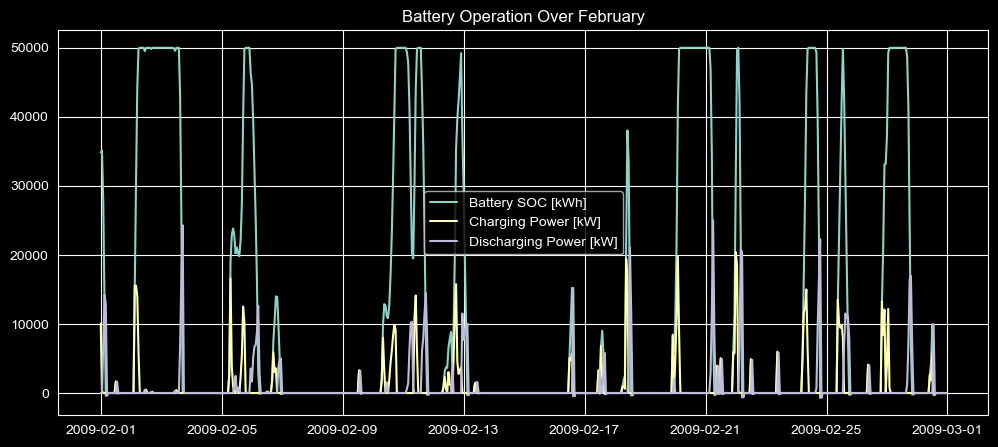

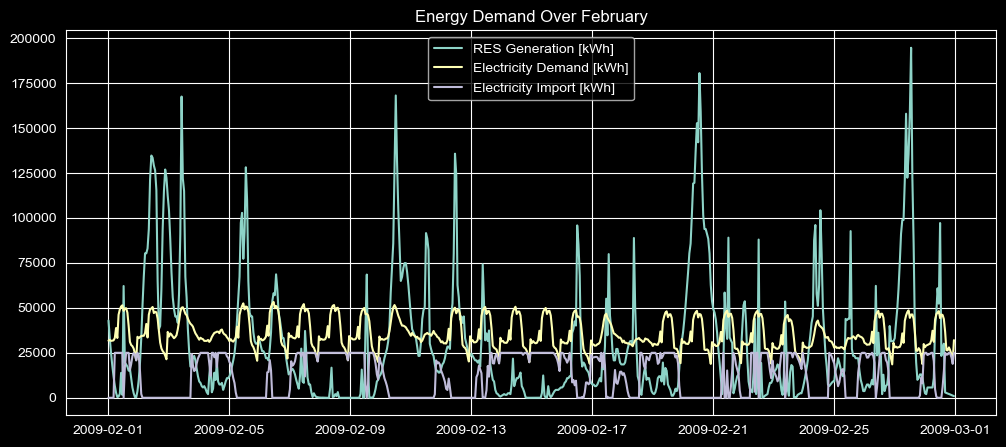

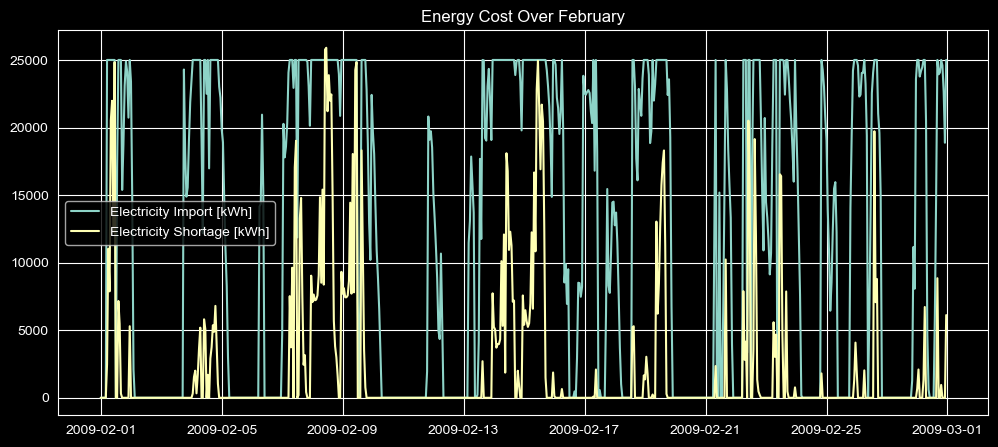

5385034.197611249
418007.0074945181 984932.3964141638 113828.01754277365 113828.01754277365 56753.476724520566 140570.37732971078 296201.86651617626 101913.52356404031 101913.52356404031 25000.399771667235 1236931.180179654 2226637.4931808384


In [255]:
plt.figure(figsize=(12,5))
plt.plot(SOC_zone2, label='Battery SOC [kWh]')
plt.plot(Charge_zone2, label='Charging Power [kW]')
plt.plot(Discharge_zone2, label='Discharging Power [kW]')
plt.legend()
plt.title("Battery Operation Over February")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Total_RES_generation, label='RES Generation [kWh]')
plt.plot(el_demand, label='Electricity Demand [kWh]')
plt.plot(Electricity_import, label='Electricity Import [kWh]')
plt.legend()
plt.title("Energy Demand Over February")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Electricity_import, label='Electricity Import [kWh]')
plt.plot(Electricity_shortage, label='Electricity Shortage [kWh]')
plt.legend()
plt.title("Energy Cost Over February")
plt.grid(True)
plt.show()

print(Complete_costs)
print(Solar_total_capex_cost_monthly, Wind_total_capex_cost_monthly, Battery_zone1_total_capex_cost_monthly, Battery_zone2_total_capex_cost_monthly, Cables_total_capex_cost_monthly, Solar_total_opex_cost_monthly, Wind_total_opex_cost_monthly, Battery_zone1_opex_cost_monthly, Battery_zone2_opex_cost_monthly, Cables_total_opex_cost_monthly, Import_cost_monthly, Lost_load_cost_monthly)

{More informaƟon:
- Design the system for your given month and year. The CAPEX of RES, transmission line and
storage must be annualized to the studied period of 1 month.
- Plan the operaƟon of the energy system for each hourly Ɵme-step.
- At each Ɵme-step, the demand in zone 1 can import electricity from outside the system under
design, unƟl a maximum import limit (MW), at a given price.
- If demand cannot be served from either RES, storage or import, the unserved demand penalty
must be accounted for in your annualized cost.

Points to address in the markdown cells of your notebook:
- Explore the trade-off in terms of your chosen KPIs (e.g. total annualized system cost, RES
curtailment, uƟlizaƟon factor of the line, unserved demand etc.) between invesƟng in
solar/wind producƟon/electricity transmission/storage.
- Consequences of using energy storage -- how does the system design change if storage is
located at the producƟon side or at the demand side?
- Address the variables that have most influence on the design, the criƟcal points, limitaƟons
and how the design could be improved.
- Support your results with attractive visualizations.

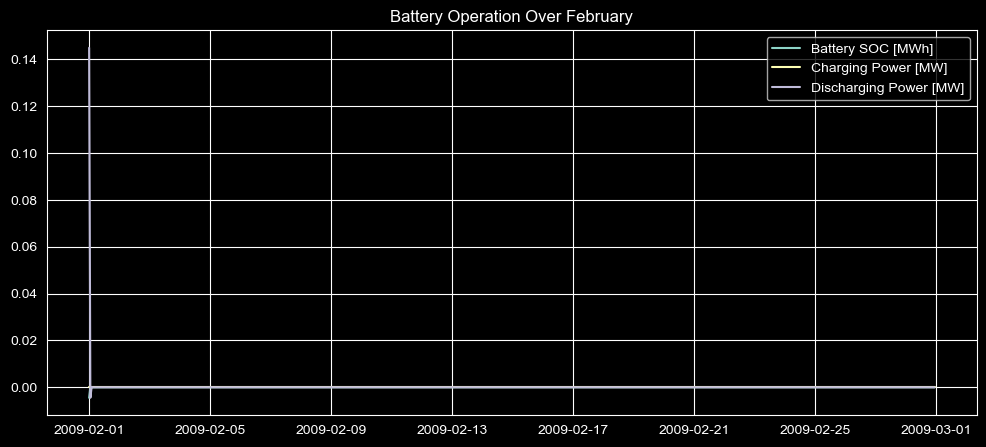

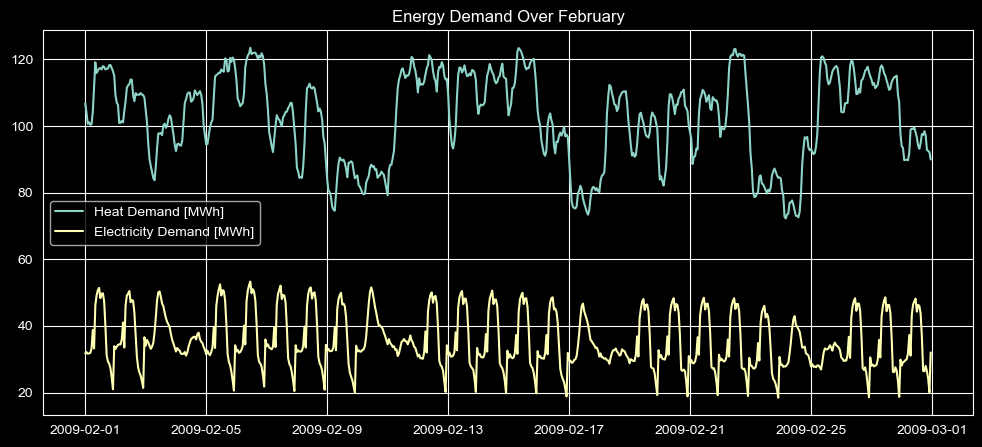

In [22]:
# INDEPENDENT EXPERIMENTATION
# stocks
wind_capacity = 10 # MW
solar_capacity = 10 # MW
battery_capacity = Li_ion_battery_capex / 1000  # from data to MWh # EUR / MWh

# stock characteristics
battery_max_charge = Li_ion_battery_max_charging_capacity / 100 * battery_capacity  # MW
battery_max_discharge = Li_ion_battery_max_discharging_capacity / 100 * battery_capacity  # MW
eta_charge = Li_ion_battery_charging_efficiency / 100 # eta is efficiency
eta_discharge = Li_ion_battery_discharging_efficiency / 100
self_discharge = Li_ion_battery_self_discharge_coefficient / 100  # per hour

#generation
wind_generation = wind_capacity * capacity_factor_wind
solar_generation = solar_capacity * capacity_factor_solar
total_res_generation = wind_generation + solar_generation

# demand
# conversions timestamp based index vs. integer
el_demand = df_p1['Electricity [MWh]'].iloc[skip : skip + len(times)]
el_demand = el_demand.set_axis(times)
heat_demand = df_p1['Heat [MWh]'].iloc[skip : skip + len(times)]
heat_demand = heat_demand.set_axis(times)

residual_load = el_demand - total_res_generation

#battery
hours = len(times)
soc = pd.Series(0.0, index=times)          # State of charge
charge = pd.Series(0.0, index=times)       # Charging power
discharge = pd.Series(0.0, index=times)    # Discharging power

el_import = pd.Series(0.0, index=times)    # Electricity to import
el_shortage = pd.Series(0.0, index=times)  # Electricity shortage

# --- Loop over hours ---
for i, t in enumerate(times):
    prev_soc = soc.iloc[i-1] if i > 0 else (battery_capacity/2)  # previous hour SOC

    if residual_load[t] < 0:  # surplus → charge battery
        charge_power = min(-residual_load[t], battery_max_charge, battery_capacity - prev_soc)
        charge[t] = charge_power
        soc[t] = prev_soc * (1 - self_discharge) + charge_power * eta_charge

    elif residual_load[t] > 0:  # deficit → discharge battery
        discharge_power = min(residual_load[t], battery_max_discharge, prev_soc)
        discharge[t] = discharge_power
        soc[t] = prev_soc * (1 - self_discharge) - discharge_power / eta_discharge

    else:  # no surplus or deficit
        soc[t] = prev_soc * (1 - self_discharge)

    # Update residual load after battery action
    residual_load[t] = residual_load[t] + charge[t] - discharge[t]

    el_import[t] = min(residual_load[t], Operational_cost_max_import_availability)
    el_shortage[t] = max(0, residual_load[t] - el_import[t])


plt.figure(figsize=(12,5))
plt.plot(soc, label='Battery SOC [MWh]')
plt.plot(charge, label='Charging Power [MW]')
plt.plot(discharge, label='Discharging Power [MW]')
plt.legend()
plt.title("Battery Operation Over February")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(heat_demand, label='Heat Demand [MWh]')
plt.plot(el_demand, label='Electricity Demand [MWh]')
plt.legend()
plt.title("Energy Demand Over February")
plt.grid(True)
plt.show()

# plt.plot(total_res_generation)
# plt.title("total generation over time")
# plt.show()

# plt.plot(el_demand)
# plt.title("total demand over time")
# plt.show()
#
# plt.plot(total_res_generation)
# plt.title("total generation over time")
# plt.show()
#
# plt.plot(residual_load)
# plt.title("residual load over time")
# plt.show()

In [23]:
# PYPSA ATTEMPT